# Singular Value Decomposition


Every real matrix $A \in \mathbb{R}^{m \times n}$ admits a factorization

$$A = U \Sigma V^\top$$

called the **singular value decomposition** (SVD). Here $U \in \mathbb{R}^{m \times m}$ and $V \in \mathbb{R}^{n \times n}$ are orthogonal matrices, and $\Sigma \in \mathbb{R}^{m \times n}$ is a diagonal matrix whose non-negative diagonal entries $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_k \geq 0$ (where $k = \min(m, n)$) are called the **singular values** of $A$. The columns of $U$ are the **left singular vectors** and the columns of $V$ are the **right singular vectors**.

The SVD is one of the most important factorizations in numerical linear algebra. It reveals the intrinsic geometry of a linear map: how it stretches space (via the singular values), and in which directions (via the singular vectors). This notebook derives the SVD from first principles via eigen-decomposition, implements it manually, validates it against `numpy`, and applies it to low-rank matrix approximation.


## Theory


The key observation is that $A^\top A \in \mathbb{R}^{n \times n}$ is **symmetric positive semi-definite** (SPSD): for any $\mathbf{x} \in \mathbb{R}^n$,

$$\mathbf{x}^\top (A^\top A) \mathbf{x} = \lVert A\mathbf{x} \rVert^2 \geq 0.$$

Since $A^\top A$ is symmetric, the **spectral theorem** guarantees a full eigen-decomposition with real, non-negative eigenvalues:

$$A^\top A = V \Lambda V^\top, \quad \Lambda = \operatorname{diag}(\lambda_1, \ldots, \lambda_n), \quad \lambda_i \geq 0.$$

We define the singular values as $\sigma_i = \sqrt{\lambda_i}$ and the right singular vectors as the corresponding eigenvectors (columns of $V$). The left singular vectors are then recovered by the relation

$$\mathbf{u}_i = \frac{A \mathbf{v}_i}{\sigma_i}, \quad \sigma_i > 0.$$

To confirm that this is consistent, we verify that $\{\mathbf{u}_i\}$ are indeed orthonormal:

$$\mathbf{u}_i^\top \mathbf{u}_j = \frac{\mathbf{v}_i^\top A^\top A \mathbf{v}_j}{\sigma_i \sigma_j} = \frac{\lambda_j \, \mathbf{v}_i^\top \mathbf{v}_j}{\sigma_i \sigma_j} = \frac{\lambda_j}{\sigma_i \sigma_j} \delta_{ij} = \delta_{ij}.$$

When $\operatorname{rank}(A) = r < m$, the $r$ left singular vectors $\{\mathbf{u}_i\}_{i=1}^r$ span $\operatorname{col}(A)$ but leave $m - r$ dimensions of $\mathbb{R}^m$ uncovered. We complete $U$ to a full orthonormal basis by appending an orthonormal basis for $\operatorname{null}(A^\top)$ — the part of $\mathbb{R}^m$ that $A$ cannot reach. The resulting $U$ is orthogonal.

**Remark.** The derivation above proceeds through $A^\top A$. An equivalent route goes through $A A^\top \in \mathbb{R}^{m \times m}$, whose eigenvectors are the left singular vectors. Both routes yield the same singular values, since the non-zero eigenvalues of $A^\top A$ and $A A^\top$ always coincide.


## Implementation


**Setup.** We import NumPy and configure SVG output for plots:


In [1]:
import numpy as np
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats("svg")


**Helper.** We define a small utility for numerical comparisons that reports pass/fail together with the maximum absolute error:


In [2]:
def allclose(a, b, atol=1e-9, label=""):
    ok = np.allclose(a, b, atol=atol)
    status = "PASS" if ok else "FAIL"
    print(f"  [{status}] {label}  (max_err={np.max(np.abs(a - b)):.2e})")
    return ok


**Null-space completion.** When $\operatorname{rank}(A) < m$, the left singular vectors from the formula $\mathbf{u}_i = A\mathbf{v}_i / \sigma_i$ do not yet span all of $\mathbb{R}^m$. We complete $U$ to a full orthonormal basis using QR decomposition on a set of random candidates:


In [3]:
def _null_space_completion(Q, target_dim):
    """Return (target_dim - Q.shape[1]) orthonormal vectors orthogonal to Q."""
    existing = Q.shape[1]
    extra = target_dim - existing
    if extra <= 0:
        return np.empty((target_dim, 0))
    rng = np.random.default_rng(seed=42)
    candidates = np.hstack([Q, rng.standard_normal((target_dim, extra + 5))])  # (1)
    full_Q, _ = np.linalg.qr(candidates, mode="complete")                      # (2)
    return full_Q[:, existing : existing + extra]


1. We stack the known columns of $U$ alongside several random vectors. The random vectors almost surely span directions not already in $U$, giving QR enough material to find the missing dimensions.
2. QR with `mode="complete"` returns a full $m \times m$ orthogonal matrix; we slice the columns $[r, r + \text{extra})$ which are exactly the new basis vectors orthogonal to the existing ones.


**Manual SVD.** We now assemble the full derivation into `svd_manual`, which follows the five-step recipe from the theory section:


In [4]:
def svd_manual(A):
    """
    Compute the full SVD of A via eigen-decomposition of AᵀA.
    Returns U (m×m), S (k,), Vt (n×n) — same convention as np.linalg.svd.

    Note: np.linalg.svd is more numerically stable; this is for pedagogy.
    """
    m, n = A.shape
    k = min(m, n)

    # Steps 1–2: eigen-decompose AᵀA  (symmetric → real eigenvalues)
    M = A.T @ A                              # (n×n)
    eigenvalues, V = np.linalg.eigh(M)       # eigh exploits symmetry   (1)

    # Step 3: sort by descending eigenvalue
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    V = V[:, idx]                            # columns are right singular vectors

    # Step 4: singular values (clip tiny negatives from floating-point noise)
    S = np.sqrt(np.maximum(eigenvalues[:k], 0.0))  # (2)

    # Step 5: left singular vectors  uᵢ = A vᵢ / σᵢ
    U = np.zeros((m, m))
    for i in range(k):
        if S[i] > 1e-12:
            U[:, i] = A @ V[:, i] / S[i]

    # Extend U to a full orthonormal basis via null-space completion
    rank = int(np.sum(S > 1e-12))
    if rank < m:
        null_basis = _null_space_completion(U[:, :rank], m)
        U[:, rank:] = null_basis

    Vt = V.T
    return U, S, Vt


1. `np.linalg.eigh` is the correct choice for symmetric matrices: it returns real eigenvalues and an orthogonal eigenvector matrix, exploiting the symmetry for efficiency and stability. `np.linalg.eig` would work but is slower and returns complex results in general.
2. Floating-point arithmetic can produce eigenvalues of $A^\top A$ that are slightly negative (order $10^{-16}$) even though $A^\top A$ is theoretically SPSD. We clip with `np.maximum(..., 0.0)` before taking the square root to avoid `nan`.


## Validation


A correct SVD must satisfy four properties simultaneously: (1) **reconstruction** $A = U \Sigma V^\top$, (2) **$U$ orthogonality** $U^\top U = I_m$, (3) **$V$ orthogonality** $V^\top V = I_n$, and (4) **singular values** are non-negative and sorted in descending order. We implement a validation function that checks all four and prints a report:


In [5]:
def validate_svd(A, label="", use_manual=False):
    """Run all four SVD correctness checks on matrix A."""
    print(f"\n{'─'*60}")
    print(f"  Matrix: {label}  shape={A.shape}  dtype={A.dtype}")
    print(f"{'─'*60}")

    if use_manual:
        U, S, Vt = svd_manual(A)
        print("  (using manual SVD via AᵀA eigen-decomposition)")
    else:
        U, S, Vt = np.linalg.svd(A, full_matrices=True)
        print("  (using np.linalg.svd reference)")

    m, n = A.shape
    k = min(m, n)
    Sigma = np.zeros((m, n))
    Sigma[:k, :k] = np.diag(S)

    allclose(A,          U @ Sigma @ Vt, label="Reconstruction:  A ≈ U Σ Vᵀ")
    allclose(np.eye(m),  U.T @ U,        label="U orthogonality: UᵀU ≈ I")
    allclose(np.eye(n),  Vt.T @ Vt,      label="V orthogonality: VᵀV ≈ I")

    non_neg     = bool(np.all(S >= -1e-12))
    sorted_desc = bool(np.all(np.diff(S) <= 1e-12))
    print(f"  [{'PASS' if non_neg else 'FAIL'}] Singular values >= 0")
    print(f"  [{'PASS' if sorted_desc else 'FAIL'}] Singular values sorted descending")
    print(f"  S = {np.round(S, 4)}")

    return U, S, Vt


**Validation on NumPy reference.** We first confirm the validator itself works by running it against `np.linalg.svd` on a square, tall, and wide matrix:


In [6]:
rng = np.random.default_rng(seed=7)

reference_cases = [
    ("square  4x4", rng.standard_normal((4, 4))),
    ("tall    6x3", rng.standard_normal((6, 3))),
    ("wide    3x6", rng.standard_normal((3, 6))),
]

for label, A in reference_cases:
    validate_svd(A, label=label, use_manual=False)



────────────────────────────────────────────────────────────
  Matrix: square  4x4  shape=(4, 4)  dtype=float64
────────────────────────────────────────────────────────────
  (using np.linalg.svd reference)
  [PASS] Reconstruction:  A ≈ U Σ Vᵀ  (max_err=6.66e-16)
  [PASS] U orthogonality: UᵀU ≈ I  (max_err=5.55e-16)
  [PASS] V orthogonality: VᵀV ≈ I  (max_err=1.33e-15)
  [PASS] Singular values >= 0
  [PASS] Singular values sorted descending
  S = [2.3537 0.6402 0.5006 0.3209]

────────────────────────────────────────────────────────────
  Matrix: tall    6x3  shape=(6, 3)  dtype=float64
────────────────────────────────────────────────────────────
  (using np.linalg.svd reference)
  [PASS] Reconstruction:  A ≈ U Σ Vᵀ  (max_err=1.33e-15)
  [PASS] U orthogonality: UᵀU ≈ I  (max_err=7.77e-16)
  [PASS] V orthogonality: VᵀV ≈ I  (max_err=5.55e-16)
  [PASS] Singular values >= 0
  [PASS] Singular values sorted descending
  S = [3.8905 2.3359 1.6459]

──────────────────────────────────────────

**Validation on manual SVD.** We now run the same suite against `svd_manual` on fresh square and tall matrices:


In [7]:
manual_cases = [
    ("square  5x5 (manual)", rng.standard_normal((5, 5))),
    ("tall    8x3 (manual)", rng.standard_normal((8, 3))),
]

for label, A in manual_cases:
    validate_svd(A, label=label, use_manual=True)



────────────────────────────────────────────────────────────
  Matrix: square  5x5 (manual)  shape=(5, 5)  dtype=float64
────────────────────────────────────────────────────────────
  (using manual SVD via AᵀA eigen-decomposition)
  [PASS] Reconstruction:  A ≈ U Σ Vᵀ  (max_err=6.94e-16)
  [PASS] U orthogonality: UᵀU ≈ I  (max_err=5.06e-14)
  [PASS] V orthogonality: VᵀV ≈ I  (max_err=3.73e-16)
  [PASS] Singular values >= 0
  [PASS] Singular values sorted descending
  S = [2.8565 2.2532 1.8277 0.735  0.1758]

────────────────────────────────────────────────────────────
  Matrix: tall    8x3 (manual)  shape=(8, 3)  dtype=float64
────────────────────────────────────────────────────────────
  (using manual SVD via AᵀA eigen-decomposition)
  [PASS] Reconstruction:  A ≈ U Σ Vᵀ  (max_err=8.88e-16)
  [PASS] U orthogonality: UᵀU ≈ I  (max_err=8.88e-16)
  [PASS] V orthogonality: VᵀV ≈ I  (max_err=4.44e-16)
  [PASS] Singular values >= 0
  [PASS] Singular values sorted descending
  S = [2.9571 2.4

## Low-Rank Approximation


The SVD exposes a natural hierarchy of "importance": the first singular value $\sigma_1$ captures the direction of greatest variance, $\sigma_2$ the next, and so on. This makes SVD the foundation of **low-rank approximation**: truncating after $r$ components gives the best possible rank-$r$ approximation to $A$.

Concretely, the **economy SVD** (also called the thin SVD) discards the columns of $U$ and $V$ associated with zero singular values:

$$A \approx A_r = \underbrace{U_r}_{m \times r} \underbrace{\Sigma_r}_{r \times r} \underbrace{V_r^\top}_{r \times n},$$

where $U_r$, $\Sigma_r$, $V_r$ retain only the top $r$ components. The **Eckart–Young theorem** states that $A_r$ is the best rank-$r$ approximation to $A$ in both the Frobenius norm and the spectral norm:

$$\lVert A - A_r \rVert_F = \sqrt{\sum_{i=r+1}^{k} \sigma_i^2}.$$

No other rank-$r$ matrix achieves a smaller Frobenius-norm error. The residual is exactly the Frobenius norm of the tail singular values — a clean formula we will verify numerically.


**Low-rank approximation function.** We implement `low_rank_approx` using the economy SVD (`full_matrices=False`), which avoids allocating the full $m \times m$ $U$ when only $r$ columns are needed:


In [8]:
def low_rank_approx(A, rank):
    """Return the best rank-r approximation of A (Eckart-Young theorem)."""
    U, S, Vt = np.linalg.svd(A, full_matrices=False)  # economy SVD  (1)
    U_r  = U[:,  :rank]                                # (m, r)
    S_r  = S[    :rank]                                # (r,)
    Vt_r = Vt[  :rank, :]                              # (r, n)
    return U_r @ np.diag(S_r) @ Vt_r


1. With `full_matrices=False`, `np.linalg.svd` returns $U \in \mathbb{R}^{m \times k}$, $S \in \mathbb{R}^k$, $V^\top \in \mathbb{R}^{k \times n}$ where $k = \min(m, n)$. This avoids allocating the $(m - k)$ columns of $U$ that span $\operatorname{null}(A^\top)$ and are unused in the reconstruction.


**Reconstruction error vs. rank.** We build a matrix with deliberate low-rank structure — a rank-$3$ signal plus small Gaussian noise — and measure the Frobenius-norm error as we vary $r$:


In [9]:
rng_lr = np.random.default_rng(seed=0)
m, n, true_rank = 20, 15, 3
L = rng_lr.standard_normal((m, true_rank))
R = rng_lr.standard_normal((true_rank, n))
A_lr = L @ R + 0.1 * rng_lr.standard_normal((m, n))  # rank-3 + noise

ranks = list(range(1, min(m, n) + 1))
errors = [np.linalg.norm(A_lr - low_rank_approx(A_lr, r), "fro") for r in ranks]

print(f"  shape={A_lr.shape}  ||A||_F = {np.linalg.norm(A_lr, 'fro'):.4f}")
for r in [1, 2, 3, 5, min(m, n)]:
    err = errors[r - 1]
    print(f"  rank-{r:2d}  ||A - A_r||_F = {err:.4f}  ({err / np.linalg.norm(A_lr, 'fro'):.1%})")


  shape=(20, 15)  ||A||_F = 30.2041
  rank- 1  ||A - A_r||_F = 14.9844  (49.6%)
  rank- 2  ||A - A_r||_F = 8.2446  (27.3%)
  rank- 3  ||A - A_r||_F = 1.4329  (4.7%)
  rank- 5  ||A - A_r||_F = 1.0466  (3.5%)
  rank-15  ||A - A_r||_F = 0.0000  (0.0%)


The error drops sharply at $r = 3$ (the true rank of the signal), confirming that the SVD has successfully separated the low-rank structure from the noise.

<br>

**Eckart–Young verification.** We numerically confirm the theorem by checking that the actual Frobenius error equals $\sqrt{\sum_{i>r} \sigma_i^2}$ for each rank:


In [10]:
_, S_lr, _ = np.linalg.svd(A_lr, full_matrices=False)

print("  Eckart-Young verification:")
for r in [1, 2, 3]:
    actual_err  = np.linalg.norm(A_lr - low_rank_approx(A_lr, r), "fro")
    optimal_err = np.sqrt(np.sum(S_lr[r:] ** 2))  # sqrt(σ_{r+1}² + … + σ_k²)
    match = "OK" if abs(actual_err - optimal_err) < 1e-9 else "FAIL"
    print(f"  rank-{r}  actual={actual_err:.6f}  "
          f"sqrt(Σ σ_i² for i>{r})={optimal_err:.6f}  [{match}]")


  Eckart-Young verification:
  rank-1  actual=14.984409  sqrt(Σ σ_i² for i>1)=14.984409  [OK]
  rank-2  actual=8.244556  sqrt(Σ σ_i² for i>2)=8.244556  [OK]
  rank-3  actual=1.432861  sqrt(Σ σ_i² for i>3)=1.432861  [OK]


Plotting the reconstruction error as a function of rank:


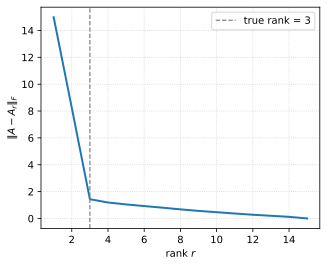

In [11]:
#| code-fold: true
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.plot(ranks, errors, linewidth=2, color="C0")
plt.axvline(true_rank, linestyle="dashed", color="gray", linewidth=1.2, label=f"true rank = {true_rank}")
plt.xlabel("rank $r$")
plt.ylabel(r"$\|A - A_r\|_F$")
plt.grid(linestyle="dotted", alpha=0.6)
plt.legend();


**Figure.** Frobenius reconstruction error $\lVert A - A_r \rVert_F$ as a function of rank $r$. The error decays smoothly, with a clear elbow at $r = 3$ where the dominant low-rank signal has been captured and only the noise floor remains.


---


■
